<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# AND Gate
and_data = {'X1': [0, 0, 1, 1],
            'X2': [0, 1, 0, 1],
            'Y':  [0, 0, 0, 1]}

df_and = pd.DataFrame(and_data)
print("AND Gate Data:")
print(df_and)


AND Gate Data:
   X1  X2  Y
0   0   0  0
1   0   1  0
2   1   0  0
3   1   1  1


In [3]:
def mp_neuron(x1, x2, weights, threshold):
    # Weighted sum
    total_input = x1 * weights[0] + x2 * weights[1]
    # Activation
    output = 1 if total_input >= threshold else 0
    return output


In [4]:
# Weights and Threshold for AND Gate
weights = [1, 1]
threshold = 2  # Output 1 only when both inputs are 1

outputs = []
for i in range(len(df_and)):
    x1, x2 = df_and.loc[i, 'X1'], df_and.loc[i, 'X2']
    y_pred = mp_neuron(x1, x2, weights, threshold)
    outputs.append(y_pred)

df_and['Predicted'] = outputs
print(df_and)


   X1  X2  Y  Predicted
0   0   0  0          0
1   0   1  0          0
2   1   0  0          0
3   1   1  1          1


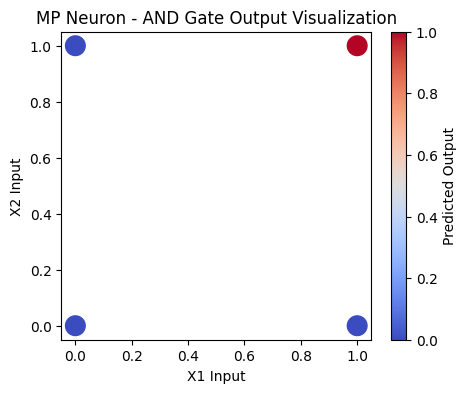

In [5]:
plt.figure(figsize=(5,4))
plt.scatter(df_and['X1'], df_and['X2'], c=df_and['Predicted'], cmap='coolwarm', s=200)
plt.title("MP Neuron - AND Gate Output Visualization")
plt.xlabel("X1 Input")
plt.ylabel("X2 Input")
plt.colorbar(label='Predicted Output')
plt.show()


In [6]:
# OR Gate
or_data = {'X1': [0, 0, 1, 1],
           'X2': [0, 1, 0, 1],
           'Y':  [0, 1, 1, 1]}
df_or = pd.DataFrame(or_data)

# Weights & Threshold
weights = [1, 1]
threshold = 1  # Output 1 when any input is 1

df_or['Predicted'] = [mp_neuron(x1, x2, weights, threshold)
                      for x1, x2 in zip(df_or['X1'], df_or['X2'])]
print("\nOR Gate:\n", df_or)



OR Gate:
    X1  X2  Y  Predicted
0   0   0  0          0
1   0   1  1          1
2   1   0  1          1
3   1   1  1          1


In [7]:
# NOT Gate
not_data = {'X': [0, 1], 'Y': [1, 0]}
df_not = pd.DataFrame(not_data)

def mp_neuron_not(x, weight, threshold):
    return 1 if (x * weight) < threshold else 0

df_not['Predicted'] = [mp_neuron_not(x, -1, 0) for x in df_not['X']]
print("\nNOT Gate:\n", df_not)



NOT Gate:
    X  Y  Predicted
0  0  1          0
1  1  0          1


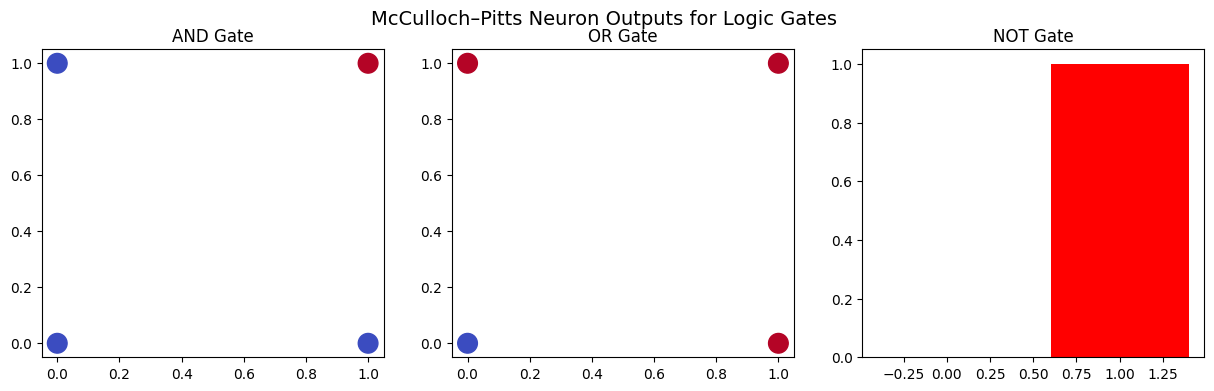

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# AND
axs[0].scatter(df_and['X1'], df_and['X2'], c=df_and['Predicted'], cmap='coolwarm', s=200)
axs[0].set_title("AND Gate")

# OR
axs[1].scatter(df_or['X1'], df_or['X2'], c=df_or['Predicted'], cmap='coolwarm', s=200)
axs[1].set_title("OR Gate")

# NOT
axs[2].bar(df_not['X'], df_not['Predicted'], color=['blue', 'red'])
axs[2].set_title("NOT Gate")

plt.suptitle("McCulloch–Pitts Neuron Outputs for Logic Gates", fontsize=14)
plt.show()
